# Evaluation on Churn Prediction Project

### Let's set up the environment and load the data

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

In [96]:
!wget $data

--2026-03-09 12:57:25--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.1’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0s      

2026-03-09 12:57:25 (207 MB/s) - ‘course_lead_scoring.csv.1’ saved [80876/80876]



In [97]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


#### Data preparation

We will check if there are any missing values, if they are we will handle them as instructed:
+ For **numerical** variables, fill any missing values with **0**
+ For **categorical** variables, fill with **NaN**

In [15]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [16]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [98]:
numerical_cols = list(df.dtypes[df.dtypes!= 'str'].index)
numerical_cols.pop() #We eliminate the response variable
numerical_cols

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [99]:
categorical_cols = list(df.dtypes[df.dtypes == 'str'].index)
categorical_cols

['lead_source', 'industry', 'employment_status', 'location']

+ Let's handle now missing data

In [100]:
for c in categorical_cols:
    df[c] = df[c].isnull().fillna('NaN')
df[categorical_cols].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [101]:
for c in numerical_cols:
    df[c] = df[c].isnull().fillna(0)
df[numerical_cols].isnull().sum()

number_of_courses_viewed    0
annual_income               0
interaction_count           0
lead_score                  0
dtype: int64

#### Evaluation framework: train/validation/test 60%/20%/20%

In [102]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [103]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `lead_score`
- `number_of_courses_viewed`
- `interaction_count`
- `annual_income`

In [104]:
from sklearn.metrics import roc_auc_score,roc_curve

In [106]:
columns = numerical_cols+categorical_cols

for c in numerical_cols:
    auc = roc_auc_score(y_train, df_train[c])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print('%16s, %.3f' % (c, auc))

number_of_courses_viewed, 0.500
   annual_income, 0.506
interaction_count, 0.500
      lead_score, 0.500


+ Just by 0.006: `annual_income` has the highest AUC

### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- 0.72
- 0.92

#### Let's prepare all X matrices with One-Hot Encoding already performed

In [108]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse = False)

train_dicts = df_train[columns].to_dict(orient = 'records')
val_dicts = df_val[columns].to_dict(orient = 'records')
test_dicts = df_test[columns].to_dict(orient = 'records')

In [109]:
X_train = dv.fit_transform(train_dicts)
X_val = dv.fit_transform(val_dicts)
X_test = dv.fit_transform(test_dicts)

#### Training the model

In [110]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:,1]


In [111]:
auc_score = roc_auc_score(y_val, y_pred)
round(auc_score, 3)

0.491

### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

* 0.145
* 0.345
* 0.545
* 0.745

In [112]:
from sklearn.metrics import precision_score, recall_score

def precision_recall_calc(y_true,y_model,threshold):
    y_pred = (y_model >= threshold)
    prec = precision_score(y_true, y_pred)
    rec = recall_score (y_true, y_pred)
    return prec, rec

precision, recall = precision_recall_calc(y_val,y_pred,0.01)
print(precision, recall)

0.5836177474402731 1.0


In [113]:
thresholds = np.linspace(0,1, 101)
precision_scores = []
recall_scores = []
for t in thresholds:
    prec, rec = precision_recall_calc(y_val,y_pred,t)
    precision_scores.append(prec)
    recall_scores.append(rec)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3

In [70]:
df_scores = pd.DataFrame()
df_scores['threshold'] = thresholds
df_scores['precision'] = precision_scores
df_scores['recall']  = recall_scores

df_scores

,threshold,precision,recall
0,0.00,0.583618,1.0
1,0.01,0.583618,1.0
2,0.02,0.583618,1.0
3,0.03,0.583618,1.0
4,0.04,0.583618,1.0
...,...,...,...
96,0.96,0.000000,0.0
97,0.97,0.000000,0.0
98,0.98,0.000000,0.0
99,0.99,0.000000,0.0


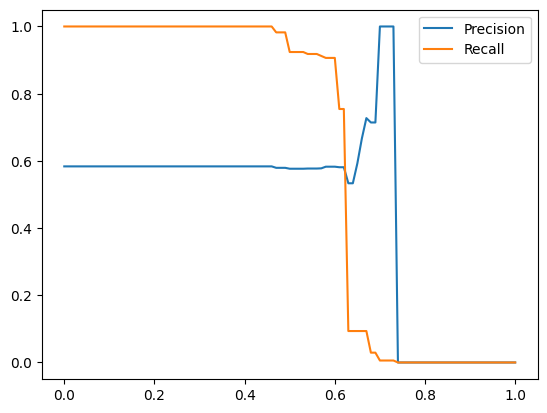

In [114]:
import matplotlib.pyplot as plt

plt.plot(df_scores.threshold, df_scores['precision'], label='Precision')
plt.plot(df_scores.threshold, df_scores['recall'], label='Recall')
plt.legend()

In [115]:
def f1_score(prec, rec):
    f1_score = 2 * (prec*rec / prec+rec)
    return f1_score

df_scores['f1_score'] = f1_score(df_scores.precision, df_scores.recall)
df_scores

,threshold,precision,recall,f1_score
0,0.00,0.583618,1.0,4.0
1,0.01,0.583618,1.0,4.0
2,0.02,0.583618,1.0,4.0
3,0.03,0.583618,1.0,4.0
4,0.04,0.583618,1.0,4.0
...,...,...,...,...
96,0.96,0.000000,0.0,NaN
97,0.97,0.000000,0.0,NaN
98,0.98,0.000000,0.0,NaN
99,0.99,0.000000,0.0,NaN


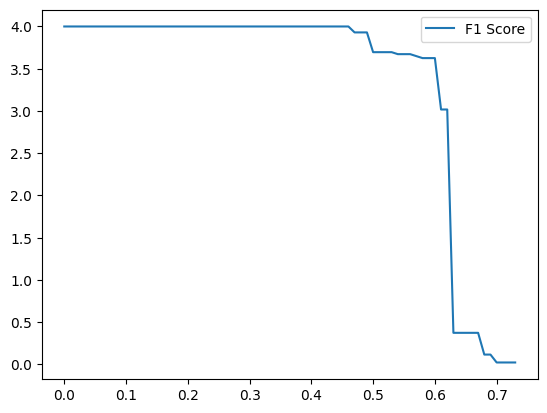

In [116]:
plt.plot(df_scores.threshold, df_scores['f1_score'], label='F1 Score')
plt.legend()

### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- 0.06
- 0.36

#### Defining training functions and fitting functions

In [124]:
def train(df, y,C=1.0):
    #We perform OneHot Encoding on the df
    dict_df = df[columns].to_dict(orient = 'records')
    dv = DictVectorizer(sparse = False)
    X = dv.fit_transform(dict_df)

    #We now train the model on said feature matrix
    model = LogisticRegression(solver = 'liblinear', C=C, max_iter=1000)
    model.fit(X,y)
    return dv, model


In [118]:
def predict(df_val, model, dv):
    #We first transform the validation set to a dict
    dicts = df_val[columns].to_dict(orient = 'records')
    X_val = dv.fit_transform(dicts)
    #We save the prediction probabilities for said model.
    y_pred = model.predict_proba(X_val)[:,1]
    return y_pred

#### Creating the KFold object

In [119]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits = 5, shuffle = True, random_state = 1)

In [123]:
scores  =[]

for train_idx, val_idx in kfold.split(df_full_train):
    #Differentiating the training and validation splits and its responses
    train_df  = df_full_train.iloc[train_idx]
    val_df = df_full_train.iloc[val_idx]

    y_train = train_df.converted.values
    y_val = val_df.converted.values

    #Fitting the model and making the predictions
    dv, model = train(train_df, y_train)
    y_pred = predict(val_df, model, dv)
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' %(np.mean(scores),np.std(scores)))

0.518 +- 0.024


### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [126]:
for C in [0.000001, 0.001, 1]:
    scores  =[]

    for train_idx, val_idx in kfold.split(df_full_train):
        #Differentiating the training and validation splits and its responses
        train_df  = df_full_train.iloc[train_idx]
        val_df = df_full_train.iloc[val_idx]

        y_train = train_df.converted.values
        y_val = val_df.converted.values

        #Fitting the model and making the predictions
        dv, model = train(train_df, y_train)
        y_pred = predict(val_df, model, dv)
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C:%.6f %.3f +- %.3f' %(C,np.mean(scores),np.std(scores)))

C:0.000001 0.518 +- 0.024
C:0.001000 0.518 +- 0.024
C:1.000000 0.518 +- 0.024
